In [21]:
# Path handling (standard library)
from pathlib import Path

# Core imports
import ionerdss as ion
from ionerdss import build_system_from_pdb

# For visualizations
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
pdb_id = "8y7s"

# Build the system using simplified API
# This should take ~10 seconds for 6bno
system = build_system_from_pdb(
    source=pdb_id,
    workspace_path=f"{pdb_id}_dir",
    # Interface detection
    interface_detect_distance_cutoff=1.5,  # Standard cutoff for protein interfaces
    #interface_detect_distance_cutoff=0.55,
    interface_detect_n_residue_cutoff=5,
    #chain_grouping_seq_threshold=0.5,
    nerdss_water_box=[500.0, 500.0, 500.0],
    nerdss_total_molecule_count = 75,
    nerdss_n_itr = 500000,
    nerdss_overlap_sep_limit = 2.0,

    # ProAffinity
    predict_affinity=True,  # Enable affinity prediction
    adfr_path='~/Documents/ADFR',  # Path to ADFR
    
    # ODE Pipeline Configuration
    ode_enabled=True,            # Now using System-compatible generator!
    ode_time_span=None,   # Auto-calculated based on NERDSS simulation time
    ode_solver_method="BDF",     # Solver for stiff systems
    ode_plot=True,               # Generate plots
    ode_save_csv=True,            # Save data to CSV

    # Transition matrix parameters
    count_transition=True,        # Enable transition matrix tracking
    transition_matrix_size=100,   # Size of matrix (max cluster size expected)
    transition_write=1000,         # Write every 1000 iterations
)

Loading ESM2 model (this will be reused for all predictions)...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Prediction 1/6: /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/structures/downloaded/8y7s-assembly1.cif chains A,B
Processing /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/structures/downloaded/8y7s-assembly1.cif...
Step 1: Converting to PDBQT format...
Detected CIF file: /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/structures/downloaded/8y7s-assembly1.cif
Converting CIF to PDB: /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/structures/downloaded/8y7s-assembly1.cif -> /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/structures/downloaded/8y7s-assembly1_converted.pdb
✓ Successfully converted to PDB format: /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/structures/downloaded/8y7s-assembly1_converted.pdb
PDBQT file already exists: /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/structures/downloaded/8y7s-assembly1_converted.pdbqt
Step 2: Running ProAffinity

2026-03-12 10:50:21 - ionerdss.pdb.8Y7S - WARNING - Cannot align chain E to representative A for orientation (different lengths or too short). Using default orientation.
2026-03-12 10:50:21 - ionerdss.pdb.8Y7S - WARNING - Cannot align chain F to representative A for orientation (different lengths or too short). Using default orientation.


Predicted binding energy: -36.5979 kJ/mol

Completed 6 predictions using shared ESM2 model
ODE results saved to: /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/ode_results/ode_solution.csv
ODE plot saved to: /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/ode_results/ode_solution.png
ODE results saved to: /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/ode_results/ode_solution_simple.csv
ODE plot saved to: /Users/yueying/Workspace/ionerdss/workspace_8Y7S_test1/1/8y7s_dir/ode_results/ode_solution_simple.png


In [23]:
# Load the ODE solution CSV
ode_csv_path = f"./{pdb_id}_dir/ode_results/ode_solution_simple.csv"
ode_data = pd.read_csv(ode_csv_path)

# Show the first 10 rows of dataframe
ode_data.head(10)

,time,A1,A2,A3,A4
0,0.000000,0.996324,0.000000,0.000000,0.000000
1,0.000228,0.907770,0.043160,0.000700,0.000033
2,0.000457,0.832075,0.078233,0.002349,0.000184
3,0.000685,0.767099,0.106657,0.004633,0.000503
4,0.000914,0.710835,0.129769,0.007295,0.001017
5,0.001142,0.661752,0.148583,0.010174,0.001721
6,0.001371,0.618316,0.164117,0.013100,0.002619
7,0.001599,0.579689,0.176915,0.016026,0.003682
8,0.001828,0.545017,0.187536,0.018887,0.004894
9,0.002056,0.513836,0.196274,0.021676,0.006228


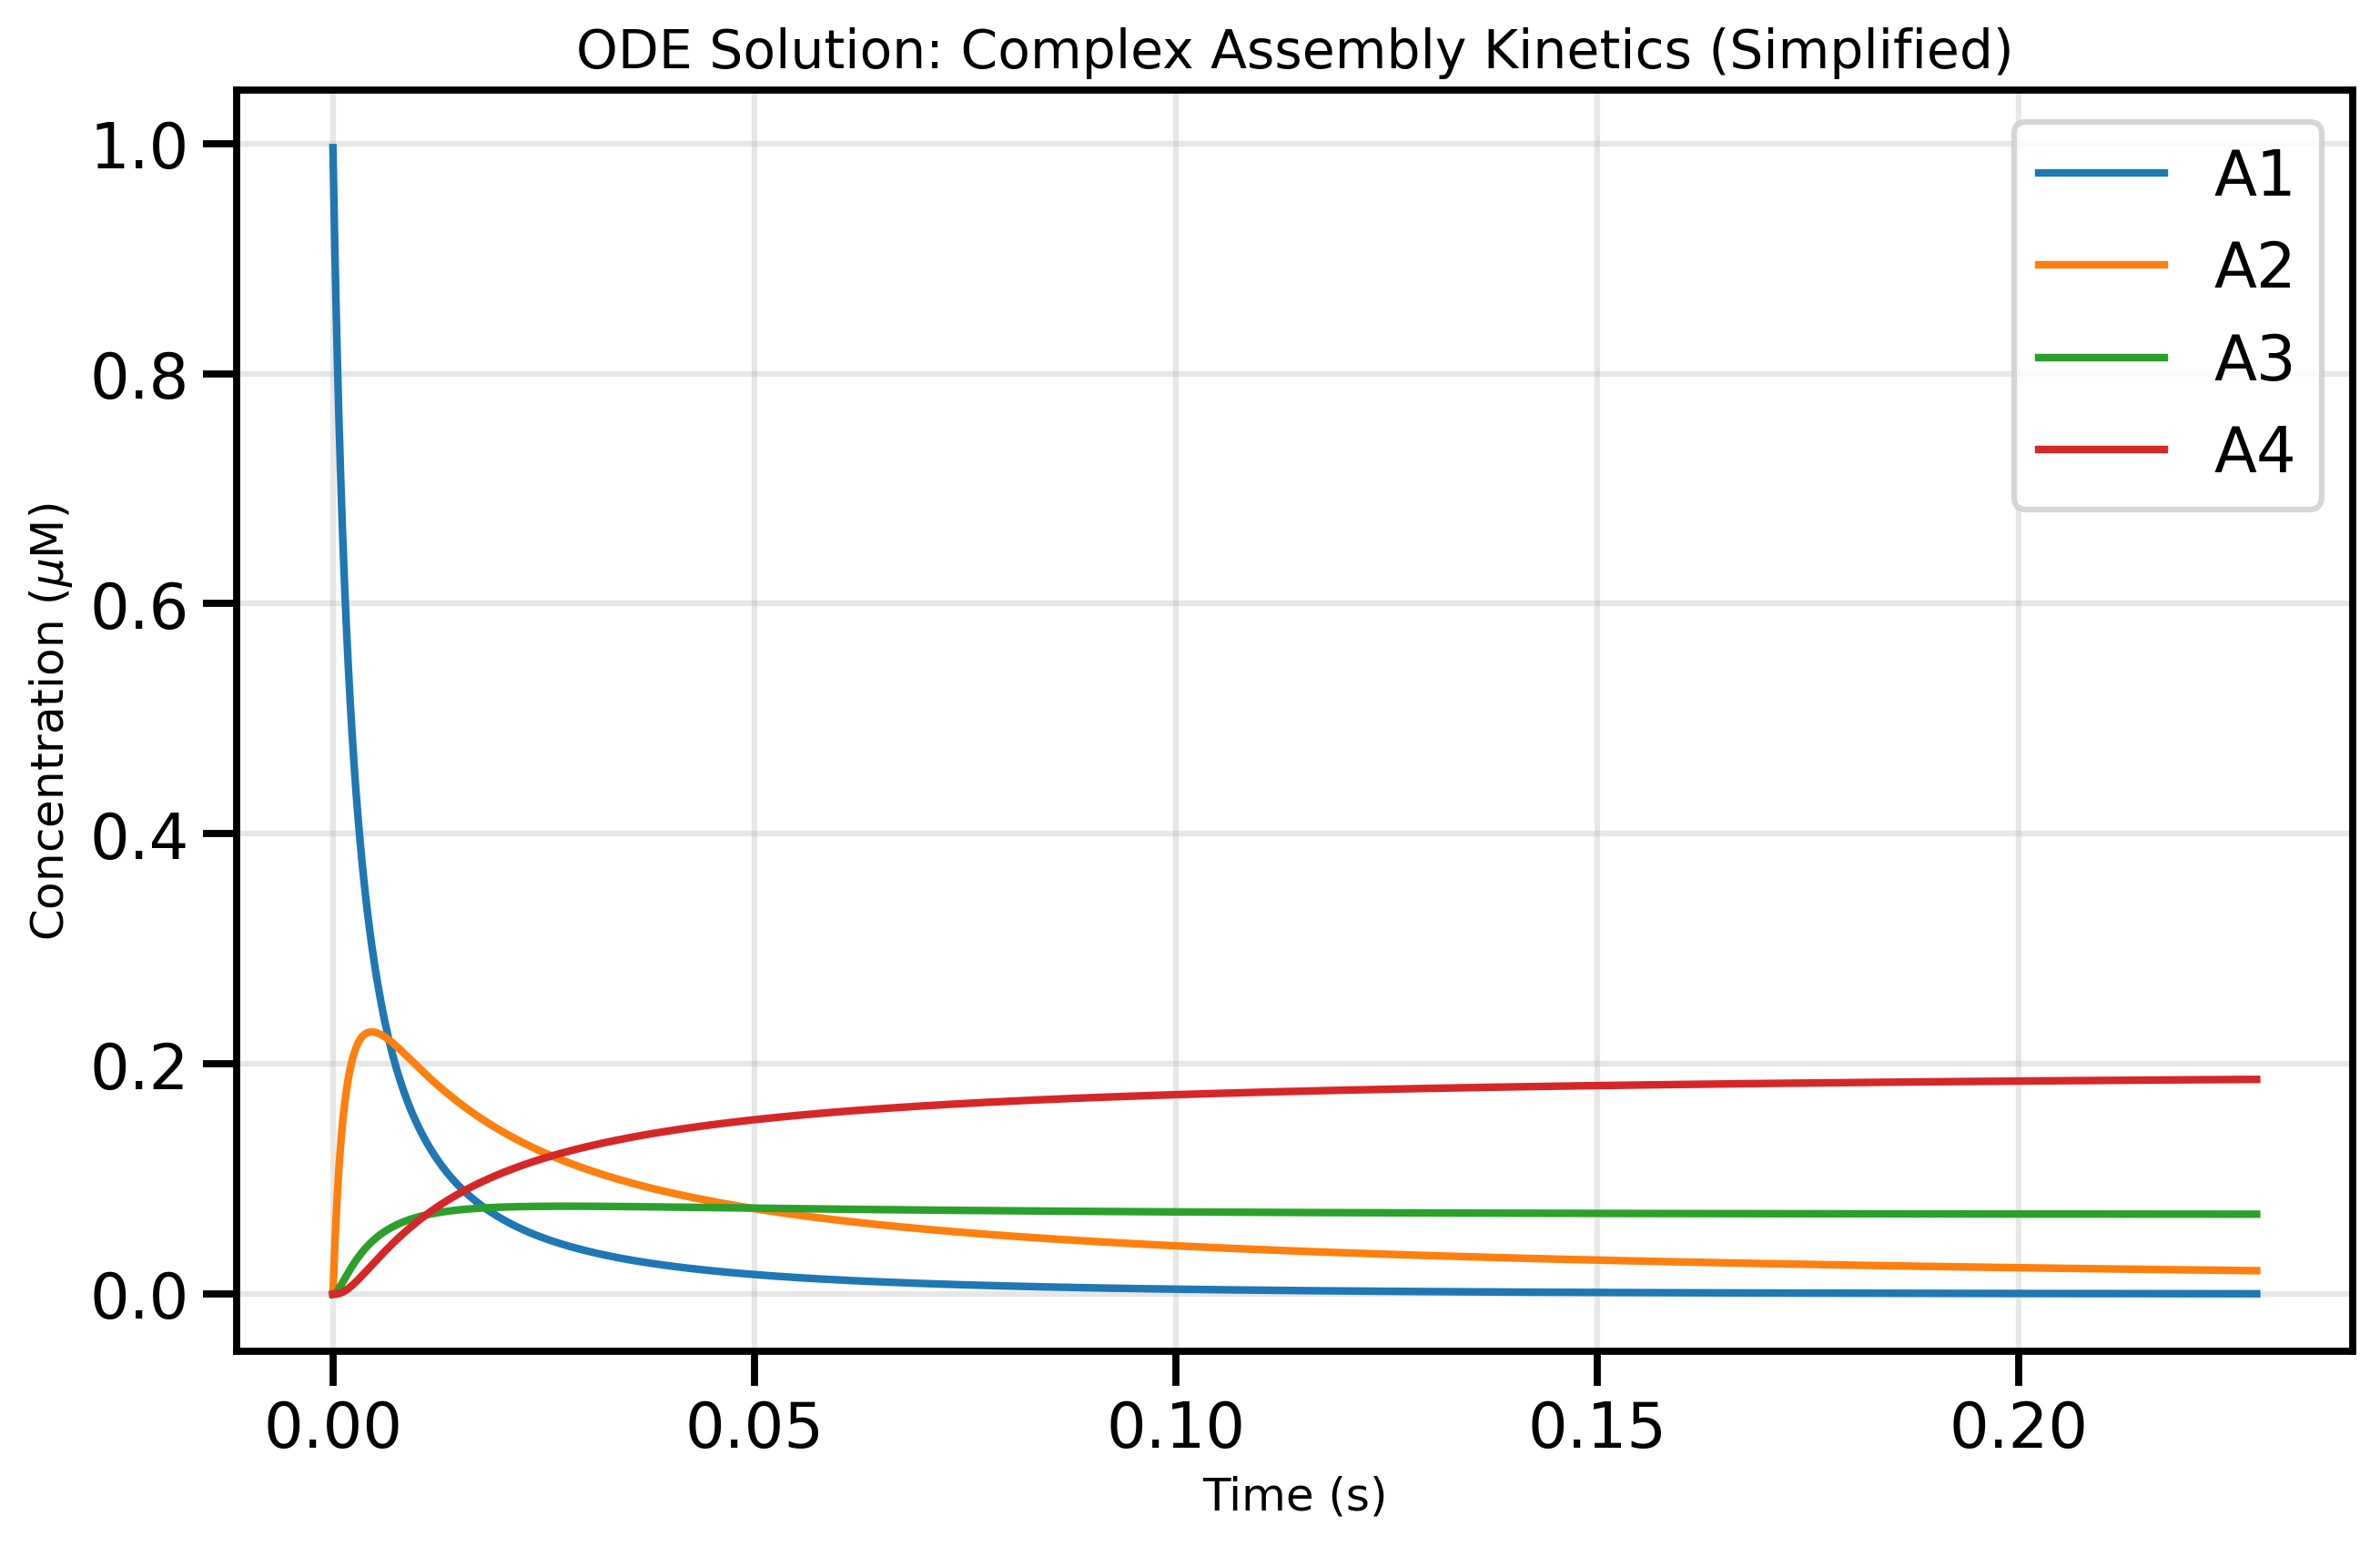

In [24]:
# import the display and Image functions from IPython.display
from IPython.display import display, Image

# Specify the path to your PNG file
image_path = f'./{pdb_id}_dir/ode_results/ode_solution_simple.png'

# Display the image
display(Image(filename=image_path))


In [25]:
# run NERDSS with subprocess
import subprocess

# Check if NERDSS is available
# nerdss_cmd should be replaced with the actual path to the NERDSS executable
nerdss_cmd = "~/Workspace/Reaction_ode/nerdss_development/bin/nerdss"
nerdss_path = Path(nerdss_cmd).expanduser() # replaces tilde with appropriate user home path

if nerdss_path.exists():
    
    # Run NERDSS
    result = subprocess.run(
        f"{nerdss_cmd} -f parms.inp",
        shell=True,
        cwd=f"{pdb_id}_dir/nerdss_files",
        capture_output=True,
        text=True
    )
    
    if result.returncode == 0:
        print("✓ NERDSS simulation completed!")
        print(f"\nCheck {pdb_id}_dir/nerdss_files/ for output files")
    else:
        print("⚠ NERDSS simulation failed")
        print(result.stderr[:500])
else:
    print("⚠ NERDSS not found at:", nerdss_cmd)

✓ NERDSS simulation completed!

Check 8y7s_dir/nerdss_files/ for output files


Found 1 simulation(s)
  [0] Simulation ID: nerdss_files


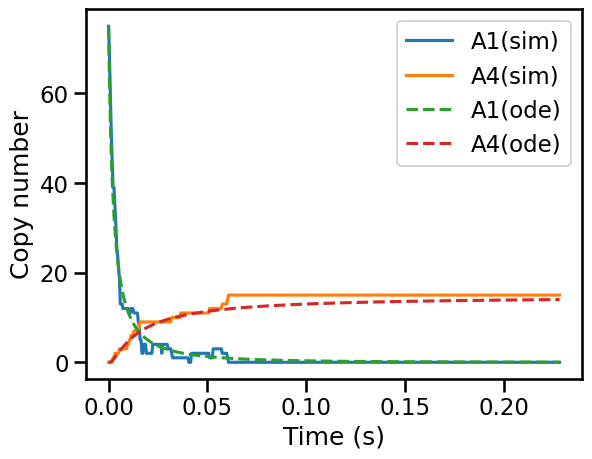

In [26]:
# Initialize Analyzer with NERDSS output directory
analysis = ion.Analyzer(f"{pdb_id}_dir")

# Display discovered simulations
print(f"Found {len(analysis.simulations)} simulation(s)")
for i, sim in enumerate(analysis.simulations):
    print(f"  [{i}] Simulation ID: {sim.id}")

#################

sim = analysis.get_simulation(0)
#complex_compositions = [{"A":n} for n in range(1,11)] # A1 through A10
complex_compositions = [{"A":1}, {"A":4}]
complex_str = ["A1", "A4"]

# get the time series data for the above complexes
time, counts = sim.get_time_series(complex_compositions)

################
# plot ODE and NERDSS side to side 
# Specify the path to your csv file
csv_path = f'./{pdb_id}_dir/ode_results/ode_solution_simple.csv'

# Display the image
df = pd.read_csv(csv_path)

# Create a new figure
plt.figure()

# Only plot first n species
plot_first_n_species = 2

# plot nerdss simulation
for i in range(plot_first_n_species):
    plt.plot(time, counts[i], label=str(complex_str[i])+'(sim)')

# ode results
for col in df.columns:
    # plot first 
    if col != "time" and col == "A1" or col == "A4":
        # df contains concentration in uM, convert to counts
        # 1 uM ~= 75 in 500 nm x 500 nm x 500 nm box
        # Change this if you used a different initial count
        initial_count_number = 75
        plt.plot(df["time"], df[col] * initial_count_number,
            label = (f"{col}(ode)"), ls = "--")

plt.xlabel("Time (s)")
plt.ylabel("Copy number")

plt.legend()
plt.show()

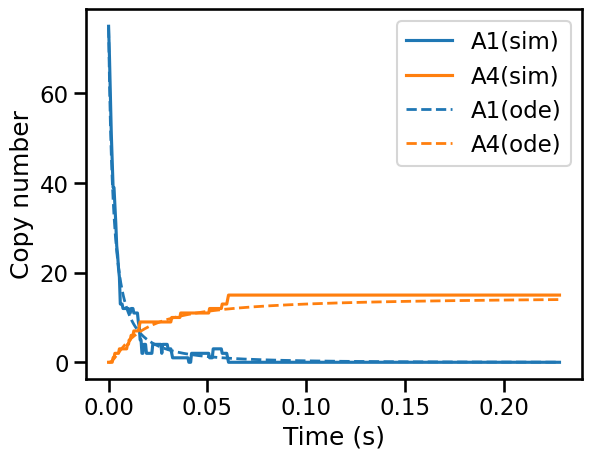

In [27]:
# Create a new figure
plt.figure()

species = ["A1", "A4"]

# plot nerdss simulation and store colors
species_colors = {}

for i, sp in enumerate(species):
    line, = plt.plot(time, counts[i], label=f"{sp}(sim)")
    species_colors[sp] = line.get_color()   # save color

# ode results
for sp in species:
    if sp in df.columns:
        initial_count_number = 75
        plt.plot(
            df["time"],
            df[sp] * initial_count_number,
            label=f"{sp}(ode)",
            linestyle="--",
            linewidth=2,
            color=species_colors[sp],  # same color as sim
        )

plt.xlabel("Time (s)")
plt.ylabel("Copy number")

plt.legend()
plt.show()

In [28]:
import seaborn as sns
sns.set_context("talk")

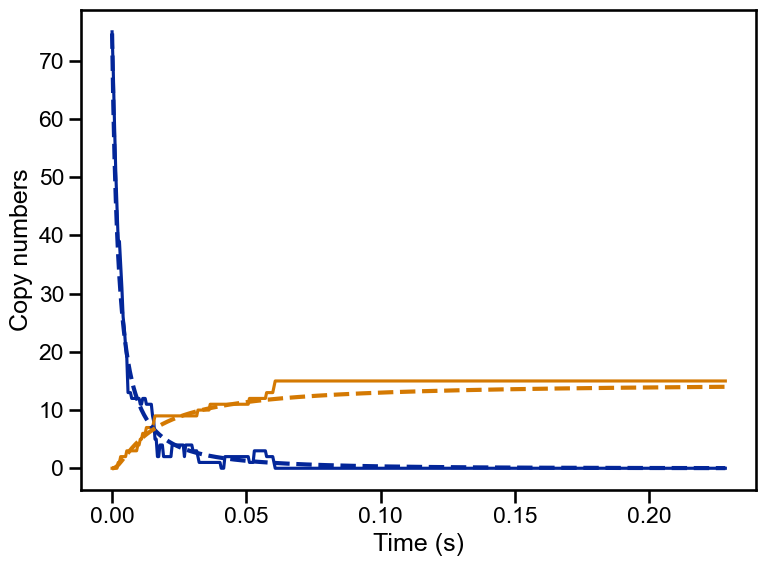

In [29]:
plt.figure(figsize=[8,6])

ax = plt.gca()

# Axis labels
ax.set_xlabel("Time (s)", fontname="Arial")
ax.set_ylabel("Copy number", fontname="Arial")

# Tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Arial")

#species = ["A1", "A2"]
species_colors = {}

sim_lines = []
ode_lines = []

# Plot NERDSS
for i, sp in enumerate(species):

    # Force monomer color
    if sp == "A1":
        line, = plt.plot(time, counts[i], label=sp, color="#032699")
    else:
        line, = plt.plot(time, counts[i], label=sp, color="#d47902")

    species_colors[sp] = line.get_color()
    sim_lines.append(line)

# Plot ODE
for sp in species:
    if sp in df.columns:
        initial_count_number = 75
        line, = plt.plot(
            df["time"],
            df[sp] * initial_count_number,
            linestyle="--",
            linewidth=3,
            color=species_colors[sp],
        )
        ode_lines.append(line)

plt.xlabel("Time (s)")
plt.ylabel("Copy numbers")

plt.tight_layout()
plt.show()